# Compare two custom `H` formats on one plot

This notebook compares block error rate vs physical error rate for:
- **Format A**: `(B+2) x (4B)` (block rows + 2 global rows)
- **Format B**: `(3B) x (4B)` (3 ancillas per 4-data block)

Both are simulated with the same Stim noise model and plotted together.

In [1]:
import numpy as np
import stim
import matplotlib.pyplot as plt

In [2]:
def make_H_plus2(num_blocks: int) -> np.ndarray:
    """Format A: (B+2) x (4B)."""
    if num_blocks <= 0:
        raise ValueError("num_blocks must be >= 1")
    top = np.kron(np.eye(num_blocks, dtype=np.uint8), np.ones((1, 4), dtype=np.uint8))
    r1 = np.tile(np.array([1, 1, 0, 0], dtype=np.uint8), num_blocks)
    r2 = np.tile(np.array([1, 0, 1, 0], dtype=np.uint8), num_blocks)
    return np.vstack([top, r1, r2]).astype(np.uint8)


def make_H_3anc_per_4data(num_blocks: int) -> np.ndarray:
    """Format B: (3B) x (4B)."""
    if num_blocks <= 0:
        raise ValueError("num_blocks must be >= 1")
    H_block = np.array(
        [
            [1, 1, 1, 1],
            [1, 1, 0, 0],
            [1, 0, 1, 0],
        ],
        dtype=np.uint8,
    )
    return np.kron(np.eye(num_blocks, dtype=np.uint8), H_block).astype(np.uint8)

In [3]:
def build_syndrome_circuit_from_H(H: np.ndarray, p_data: float = 0.02, p_meas: float = 0.0) -> stim.Circuit:
    """One-round X-noise memory circuit with Z-check syndrome extraction from H."""
    H = (H % 2).astype(np.uint8)
    m, n = H.shape

    data = list(range(n))
    anc = list(range(n, n + m))

    circuit = stim.Circuit()
    circuit.append("R", data + anc)
    circuit.append("X_ERROR", data, float(p_data))

    for i in range(m):
        a = anc[i]
        support = [j for j, bit in enumerate(H[i]) if bit]
        circuit.append("H", [a])
        for q in support:
            circuit.append("CZ", [a, q])
        circuit.append("H", [a])
        if p_meas > 0:
            circuit.append("X_ERROR", [a], float(p_meas))
        circuit.append("M", [a])
        circuit.append("DETECTOR", [stim.target_rec(-1)])

    circuit.append("M", data)
    return circuit


def sample_syndrome_dataset(circuit: stim.Circuit, H: np.ndarray, shots: int = 1000):
    m, n = H.shape
    sampler = circuit.compile_sampler()
    meas = sampler.sample(shots=shots).astype(np.uint8)
    syndromes = meas[:, :m]
    data_meas = meas[:, m:m+n]
    return syndromes, data_meas


def build_min_weight_syndrome_lut(H: np.ndarray):
    """Exact min-weight syndrome LUT (feasible for small n, e.g. n=8)."""
    H = (H & 1).astype(np.uint8)
    m, n = H.shape
    lut = {}
    for mask in range(1 << n):
        e = np.fromiter(((mask >> j) & 1 for j in range(n)), dtype=np.uint8, count=n)
        syn = tuple(((H @ e) & 1).tolist())
        w = int(mask.bit_count())
        if syn not in lut or w < lut[syn][0]:
            lut[syn] = (w, e.copy())
    return {k: v[1] for k, v in lut.items()}


def decode_batch(syndromes: np.ndarray, lut: dict, n: int) -> np.ndarray:
    out = np.zeros((len(syndromes), n), dtype=np.uint8)
    for i, s in enumerate(syndromes):
        out[i] = lut.get(tuple((s & 1).tolist()), np.zeros(n, dtype=np.uint8))
    return out


def evaluate_block_error_rate(H: np.ndarray, p_data: float, p_meas: float, shots: int, lut: dict):
    circuit = build_syndrome_circuit_from_H(H, p_data=p_data, p_meas=p_meas)
    syndromes, data_meas = sample_syndrome_dataset(circuit, H, shots=shots)
    e_hat = decode_batch(syndromes, lut=lut, n=H.shape[1])
    fails = np.any((e_hat ^ data_meas) != 0, axis=1)
    return float(np.mean(fails))

Format A shape: (6, 16) (B+2 x 4B)
[[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 0]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]]

Format B shape: (12, 16) (3B x 4B)
[[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]]
p=0.2 | Format A=0.804740 | Format B=0.356205
p=0.1 | Format A=0.417545 | Format B=0.106850
p=0.05 | Format A=0.155550 | Format B=0.028670
p=0.02 | Format A=0.031775 | Format B=0.004535
p=0.01 | Format A=0.008490 | Format B=0.001285
p=0.005 | Format A=0.002075 | Format B=0.000295
p=0.002 | Format

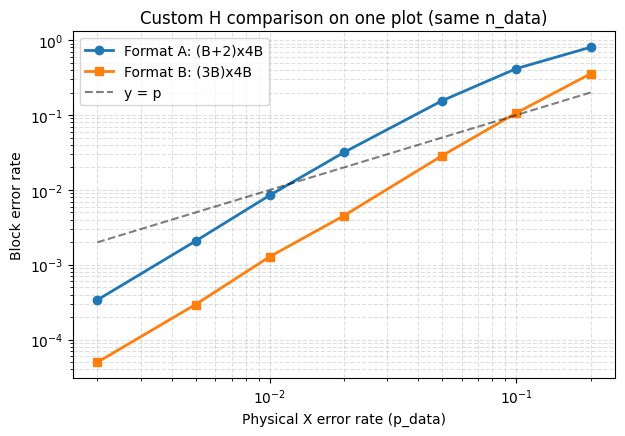

In [5]:
# --- Comparison run: same n_data for both H formats, single plot ---
num_blocks = 4  # keeps both matrices small (n_data = 8)
p_meas = 0.0
shots = 200_000
p_data_values = np.array([0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002], dtype=float)

H_a = make_H_plus2(num_blocks)
H_b = make_H_3anc_per_4data(num_blocks)

print("Format A shape:", H_a.shape, "(B+2 x 4B)")
print(H_a)
print("\nFormat B shape:", H_b.shape, "(3B x 4B)")
print(H_b)

lut_a = build_min_weight_syndrome_lut(H_a)
lut_b = build_min_weight_syndrome_lut(H_b)

err_a = []
err_b = []

for p in p_data_values:
    e_a = evaluate_block_error_rate(H_a, p_data=float(p), p_meas=p_meas, shots=shots, lut=lut_a)
    e_b = evaluate_block_error_rate(H_b, p_data=float(p), p_meas=p_meas, shots=shots, lut=lut_b)
    err_a.append(e_a)
    err_b.append(e_b)
    print(f"p={p:.4g} | Format A={e_a:.6f} | Format B={e_b:.6f}")

plt.figure(figsize=(7, 4.5))
plt.loglog(p_data_values, err_a, marker="o", linewidth=2, label="Format A: (B+2)x4B")
plt.loglog(p_data_values, err_b, marker="s", linewidth=2, label="Format B: (3B)x4B")
plt.loglog(p_data_values, p_data_values, "k--", alpha=0.5, label="y = p")
plt.xlabel("Physical X error rate (p_data)")
plt.ylabel("Block error rate")
plt.title("Custom H comparison on one plot (same n_data)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()